### 부스팅(boost)
- 모델을 순차적으로 학습
- 이전 모델이 잘못 맞추거나 확률이 애매한 경우 데이터에 가중치를 중가 -> 다음 모델에서 집중 학습
- 단순 모델들을 결합하여 강력 모델로 생성
- 장점
    - 편향 감소 -> 예측의 확률이 올라간다.
    - 단순한 모델들을 이어서 학습하기 때문에 성능이 많이 올라간다.
- 단점
    - 순차적으로 학습 -> 병렬화 어려움 -> 학습 속도가 느려짐
    - 학습의 횟수가 너무 많은 경우 -> 과적합 위험
    - 파라미터 튜닝이 중요
- 대표 알고리즘
    - AdaBoost
        - 오차가 더 큰 샘플에 더 높은 가중치를 부여
        - 각각의 모델들이 가중치가 조정이 된 데이터셋을 이용하여 학습
        - 최종 모델에서는 가중치의 합산으로 결정
    - Gradient Boosting(GBM)
        - 이전 모델의 잔차를 예측하는 새로운 모델을 새로운 추가
        - 손실 함수 직접 최적화
        - 계산량이 많음
    - XGBoost
        - GBM을 개선한 알고리즘
        - 규제, 병렬 학습 지원 -> 병렬 지원을 통해서 시간 감소 -> 규제를 통해서 과적합 방지
        - 대표적인 부스팅 알고리즘
        - 해당 모델은 추가적인 라이브러리 설치 필요
    - LightGBM
        - XGBoost에 비해 속도면에서 우수
        - 히스토그램 기반 학습을 통해서 대용량 데이터의 처리에 특화
    - CatBoost
        - 범주형 데이터들은 자동 처리
        - 비교적 튜닝이 간단

#### AdaBoost (분류)
- 초기에는 모든 샘플의 가중치를 동일하게 부여
- 첫번째 모델에서는 약한 모델을 학습 -> 잘못 분류한 샘플에 대해서 가중치를 중가
- 가중치가 증가한 데이터를 이용하여 다음 모델에서 학습하여 더 잘 맞추도록 집중 학습
- parameter
    - estimator(base_estimator 매개변수는 sklearn의 구버전에서 사용)
        - 기본값 : DecisionTreeClassifier(max_depth=1)
        - 모델 리스트
            - DecisionTreeClassifier : 매개변수의 값들을 바꿔서 사용 가능 -> 의사결정나무
            - LogisticRegression : 신형 분류 모델
            - SVC(probability = True) : 확률 예측을 True로 변경해야 사용이 가능
    - n_estimator
        - 기본값 : 50
        - 일반적으로 50 ~ 500
        - 모델의 개수
            - 개수가 너무 많아지면 시간이 증가, 과적합 위험성 증가
    -learning_rate
        - 기본값 : 1.0
        - 각 단계별 기여도(가중치)
        - 일반적으로 0.1 ~ 1.0
        - n_estimator와 상호 보완적으로 설정 (rate를 작게하면 모델의 개수를 증가시킴)
        - 약한 모델의 기여도를 조절하는 스케일링 값
        - 값이 작은 경우 -> 각 단계 별 영향이 줄어듬 -> 많은 모델이 필요
        - 데이터의 크기 / 복잡도가 클수록 모델의 개수를 늘리고 줄여주는것이 유리
        - 작은 데이터인 경우 데이터의 개수를 줄이고 기여도를 증가시키는 게 유리
    - algorithm
        - 기본값 : SAMME.R
        - SAMME.R : 확률을 사용, 보통 시간이 빠르고 성능이 우수
        - SAMME : 클래스 별 점수를 기반(확률 필요 없음)
- 속성
    - estimators_
        - 학습된 모델들의 리스트
    - estimators_weights_
        - 각 모델들의 가중치 (분류 중요)
    - estimators_errors_
        - 각 단계별 오차율
    - feature_importances_
        - feature별 중요도 (가중치의 합)
- 메서드
    - staged_predict(X) / staged_predict_proba(X)
        - 각 단계별 누적 모델의 예측을 순차적으로 제공 (학습 곡선)


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

In [3]:
body=pd.read_csv('../data/bodyPerformance.csv')
body.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


In [4]:
#gender 컬럼에 M -> 0, F -> 1
body['gender']=body['gender'].map(
    lambda x : 0 if x == 'M' else 1
)

In [5]:
#class 값 1,2,3,4 형태로 변환
body['class'] = body['class'].map(
    {
        'A' : 1,
        'B' : 2,
        'C' : 3,
        'D' : 4
    }
)

In [7]:
body.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  int64  
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  int64  
dtypes: float64(10), int64(2)
memory usage: 1.2 MB


In [10]:
x = body.drop('class', axis=1)
y = body['class']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
clf=AdaBoostClassifier()
clf.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [14]:
pred=clf.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           1       0.59      0.61      0.60       685
           2       0.41      0.49      0.45       662
           3       0.51      0.45      0.48       650
           4       0.78      0.70      0.73       682

    accuracy                           0.56      2679
   macro avg       0.57      0.56      0.57      2679
weighted avg       0.57      0.56      0.57      2679



In [16]:
#AdaBoost에서 하이퍼파라미터(매개변수) 수정
#모델의 개수를 증가시키면서 기여도를 줄여준다.
clf2=AdaBoostClassifier(
    n_estimators=500, learning_rate=0.1
)

In [21]:
clf2.fit(X_train,y_train)

pred2=clf2.predict(X_test)

print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           1       0.75      0.78      0.76       685
           2       0.53      0.63      0.58       662
           3       0.66      0.62      0.64       650
           4       0.92      0.77      0.84       682

    accuracy                           0.70      2679
   macro avg       0.72      0.70      0.71      2679
weighted avg       0.72      0.70      0.71      2679



In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
clf3=AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=4),
    n_estimators=500, learning_rate=0.1
)

In [24]:
clf3.fit(X_train,y_train)

pred3=clf3.predict(X_test)

print(classification_report(y_test,pred3))

              precision    recall  f1-score   support

           1       0.75      0.78      0.76       685
           2       0.53      0.63      0.58       662
           3       0.66      0.62      0.64       650
           4       0.92      0.77      0.84       682

    accuracy                           0.70      2679
   macro avg       0.72      0.70      0.71      2679
weighted avg       0.72      0.70      0.71      2679



In [26]:
#AdaBoost에서 컬럼별 중요도가 어떤 컬럼이 가장 높은가?
importances=clf3.feature_importances_
importances

array([0.12470385, 0.02325894, 0.01757307, 0.05239439, 0.04655286,
       0.00341321, 0.00138066, 0.04373685, 0.46171545, 0.19803323,
       0.02723749])

In [27]:
x.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm'],
      dtype='object')

In [29]:
feature_df=pd.DataFrame(zip(x.columns, importances), columns=['feature_name','importance'])

In [31]:
#importance에 따라 내림차순 정렬
feature_df.sort_values('importance',ascending=False).head()

,feature_name,importance
8,sit and bend forward_cm,0.461715
9,sit-ups counts,0.198033
0,age,0.124704
3,weight_kg,0.052394
4,body fat_%,0.046553


#### AdaBoost (회귀)
- 여러 개의 약한 회귀 모델을 순차적으로 학습하여 이전 단계의 오차를 줄이도록 가중치를 조절하여 높은 성능의 회귀 모델을 생성
- parameter
    - estimator
        - 기본값 : DecisionTreeRegression(max_depth=3)
        - DecisionTreeRegression : 매개변수들을 변경하여 사용 가능
        - Ridge : 릿지 모델 (L2 패널티)
        - SVR : 서포트 벡터 머신 (max_iter 값 조절)
    - loss
        - 기본값 : linear
        - 오차에 대한 가중치의 변환 방식
        - linear : 기본적인 선형 업데이트
        - square : 제곱, 큰 오차에 더 민감하게 반응
        - exponential : 지수, 매우 큰 오차에 더 강하게 패널티

In [46]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [47]:
car = pd.read_csv('../data/CarPrice_Assignment.csv')

In [48]:
df = car.select_dtypes('number')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   wheelbase         205 non-null    float64
 3   carlength         205 non-null    float64
 4   carwidth          205 non-null    float64
 5   carheight         205 non-null    float64
 6   curbweight        205 non-null    int64  
 7   enginesize        205 non-null    int64  
 8   boreratio         205 non-null    float64
 9   stroke            205 non-null    float64
 10  compressionratio  205 non-null    float64
 11  horsepower        205 non-null    int64  
 12  peakrpm           205 non-null    int64  
 13  citympg           205 non-null    int64  
 14  highwaympg        205 non-null    int64  
 15  price             205 non-null    float64
dtypes: float64(8), int64(8)
memory usage: 25.8 K

In [50]:
df.drop('car_ID',axis=1,inplace=True)

In [51]:
x = df.drop('price',axis=1)
y = df['price']

In [52]:
X_train,X_test,y_train,y_test=train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [53]:
reg=AdaBoostRegressor()

In [54]:
reg.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [55]:
pred = reg.predict(X_test)

In [56]:
print('MAE : ', round(mean_absolute_error(y_test, pred), 2))
print('R2 : ', round(r2_score(y_test, pred), 2))

MAE :  2004.17
R2 :  0.9


In [58]:
reg2 = AdaBoostRegressor(n_estimators=500, learning_rate=0.1)

In [60]:
reg2.fit(X_train,y_train)
pred2 = reg2.predict(X_test)

print('MAE : ', round(mean_absolute_error(y_test, pred2), 2))
print('R2 : ', round(r2_score(y_test, pred2), 2))

MAE :  1972.8
R2 :  0.91


In [61]:
import matplotlib.pyplot as plt

In [63]:
list(reg2.staged_predict(X_test))

[array([35685.33333333, 16035.6       ,  8076.21830986, 16035.6       ,
        35685.33333333,  8076.21830986,  8076.21830986,  8076.21830986,
         8076.21830986,  8076.21830986, 16035.6       ,  8076.21830986,
        16035.6       , 12007.        , 31966.83333333,  8076.21830986,
         8076.21830986, 16035.6       ,  8076.21830986,  8076.21830986,
        12007.        , 16035.6       ,  8076.21830986,  8076.21830986,
         8076.21830986, 35685.33333333, 12007.        , 16035.6       ,
         8076.21830986, 16035.6       , 35685.33333333,  8076.21830986,
         8076.21830986, 20933.75      ,  8076.21830986, 35685.33333333,
         8076.21830986, 16035.6       ,  8076.21830986, 16035.6       ,
         8076.21830986,  8076.21830986, 16035.6       ,  8076.21830986,
         8076.21830986,  8076.21830986,  8076.21830986,  8076.21830986,
        12007.        , 16035.6       ,  8076.21830986, 16035.6       ,
         8076.21830986, 12007.        ,  8076.21830986, 16035.6 

In [64]:
#각 단계별 예측값을 이용하여 MAE를 구하여 그래프로 시각화
mae_list=[]

for stage_pred in list(reg2.staged_predict(X_test)):
    #stage_pred : 각 단계별 예측값(1차원 데이터)
    mae = mean_absolute_error(y_test,stage_pred)
    mae_list.append(mae)

mae_list

[2556.9588460548243,
 2827.702537009611,
 2233.4051400092912,
 2233.4051400092912,
 2177.7293595729516,
 2256.033074245458,
 2061.3400083966517,
 2070.915570760516,
 1789.280371255643,
 1833.3576737477072,
 1882.734777494698,
 1885.742924050263,
 1876.4674507087898,
 1919.6348694590818,
 1998.6332770618735,
 1982.1841633437061,
 1954.830203195196,
 1967.2517095366645,
 1913.24715115037,
 1980.2769190159274,
 1945.6901893952365,
 1928.000344815211,
 1923.9371414271734,
 1925.6311980710339,
 1943.1150813610484,
 1924.8891146667818,
 1928.0657815808622,
 1872.4811372809324,
 1903.8699507078259,
 1885.3230653220464,
 1863.0102868552904,
 1895.6571452219584,
 1929.2709785192903,
 1900.0366806145007,
 1905.9112132351063,
 1908.2111512385775,
 1906.3558288525626,
 1932.4222840089212,
 1926.2506810232805,
 1895.726112977784,
 1883.2665109073787,
 1868.9266266463874,
 1859.9462961354614,
 1866.2481333542248,
 1885.8583830627804,
 1846.744299680736,
 1861.0750437472675,
 1870.7042606455548,
 187

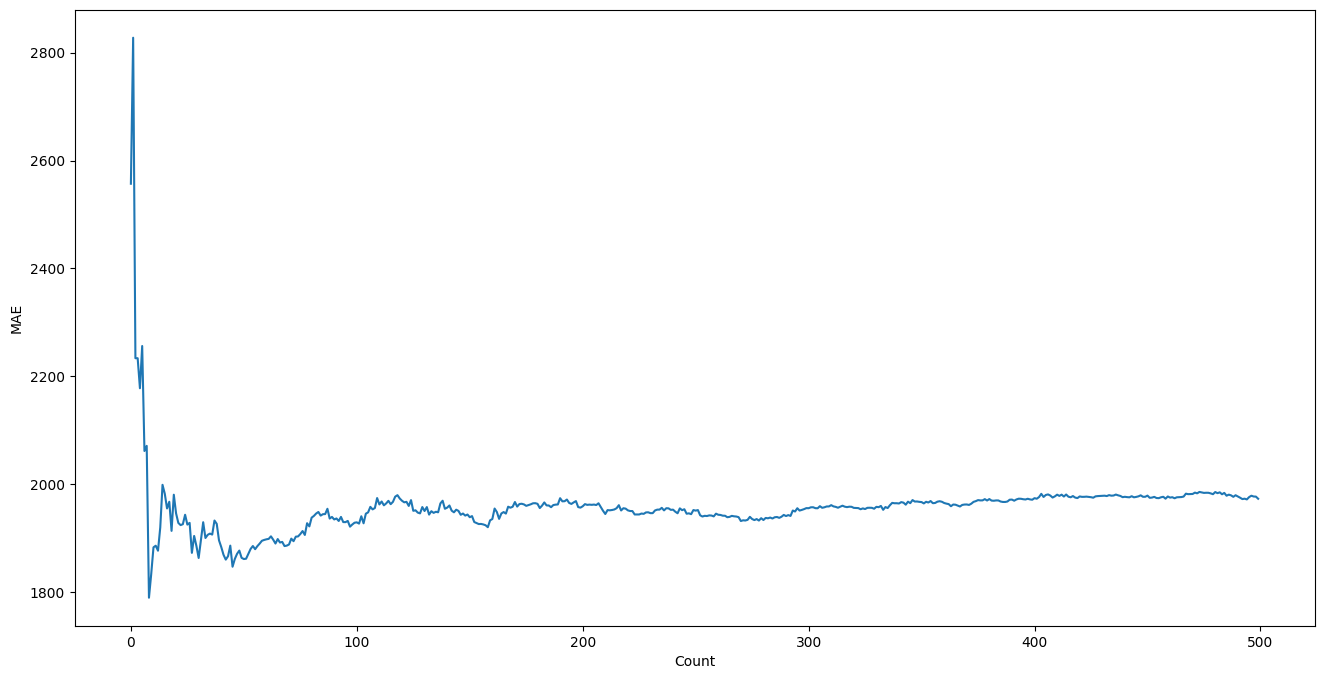

In [65]:
#평균 절대 오차 변화를 그래프로 시각화
plt.figure(figsize=(16,8))

plt.plot(mae_list)

plt.xlabel('Count')
plt.ylabel('MAE')

plt.show()

In [ ]:
importance = reg2.feature_importances_
cols=x.columns

importance_df = pd.DataFrame(
    zip(cols, importance),
    columns=['feature_name','importance']
)

importance_df.sort_values('importance',ascending=True,inplace=True)

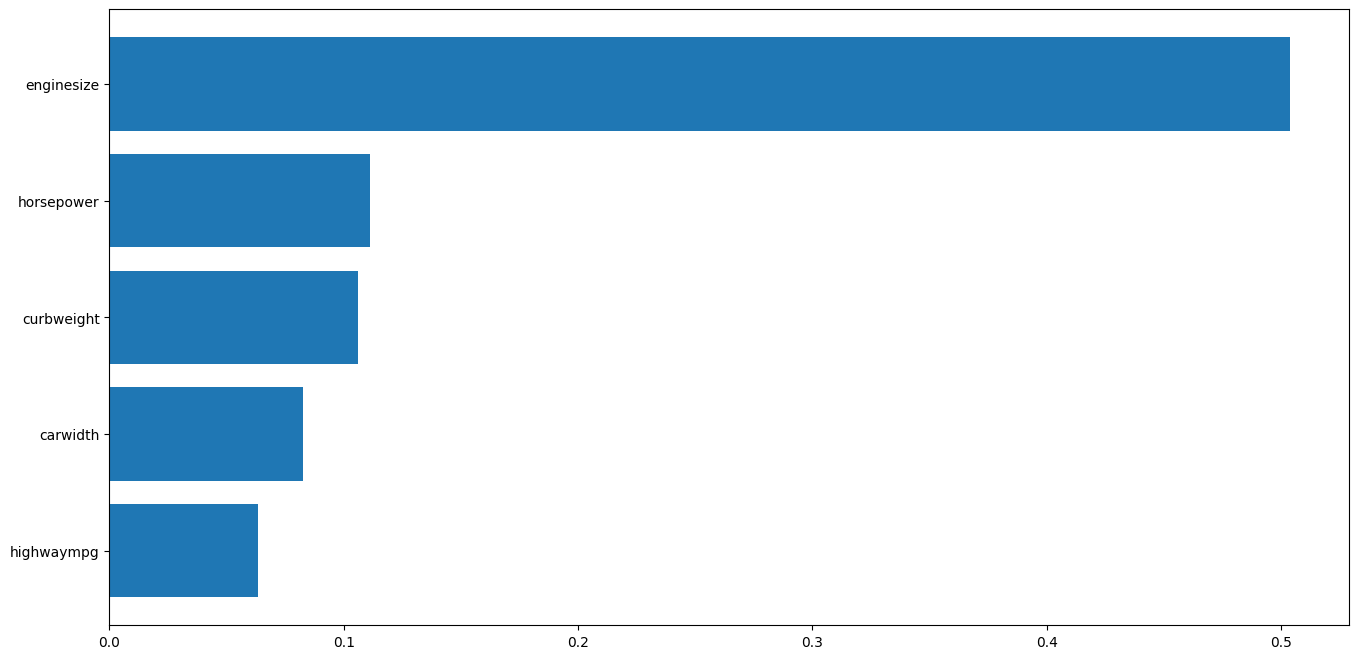

In [73]:
plt.figure(figsize=(16,8))

plt.barh(importance_df['feature_name'].tail(), importance_df['importance'].tail())

plt.show()